# 신뢰도 
- 측정 척도들이 측정하려고 의도하는 것을 얼마나 정확하고 일관되게 측정하는 지를 나타내는 수치
- 동일한 대상을 일관된 결과로 산출하는 정도
- 신뢰도가 높다 = 어떤 개념을 측정하기 위해 고안된 서로 다른 측정도구가 같은 결과를 산출한다. = 동일한 측정도구로 시간간격을 두고 측정했을 때, 두 결과의 일치도가 높다.
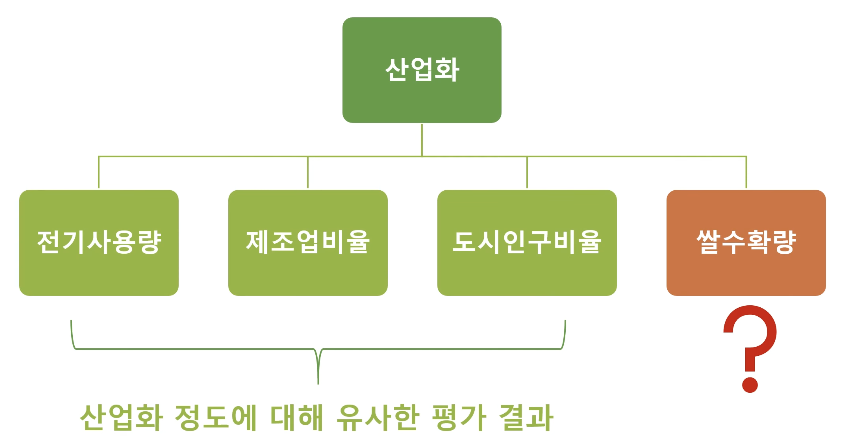

# 크론바흐 알파계수 
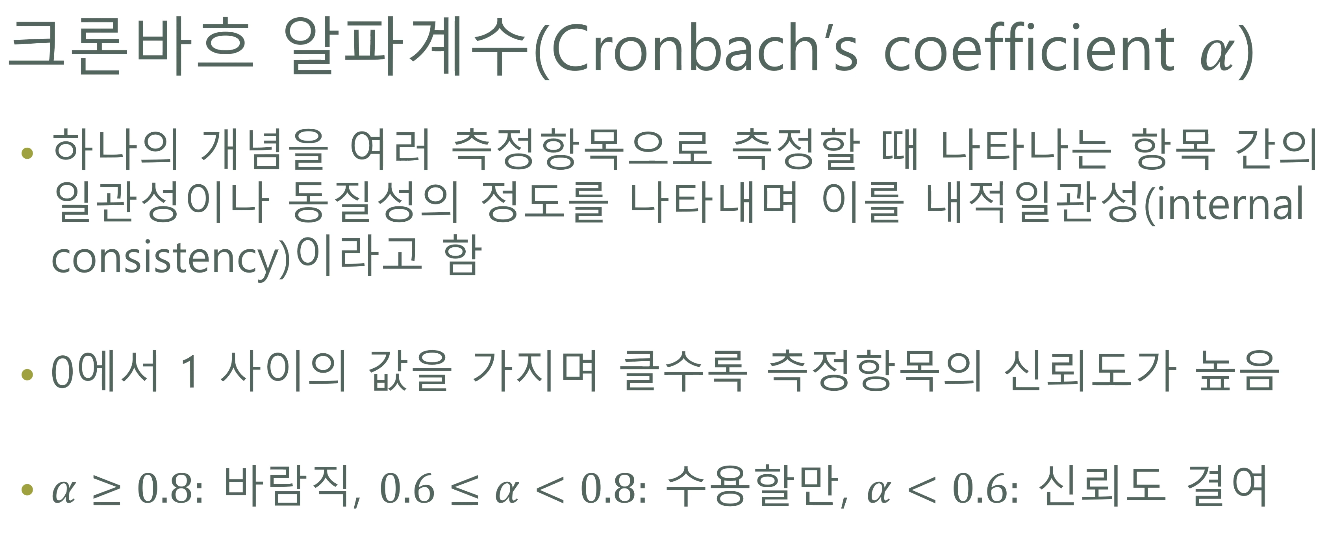

In [6]:
import pandas as pd
import pingouin as pg  # Cronbach’s alpha 지원

# 미국의 SAT 시험 결과 데이터
# ACT : 전체 점수
# SATV : 언어 영역 점수 
# SATQ : 수리 영역 점수
df = pd.read_csv("ability.csv")

# 1. 데이터 확인
df

,gender,education,age,ACT,SATV,SATQ
0,2,3,19,24,500,500.0
1,2,3,23,35,600,500.0
2,2,3,20,21,480,470.0
3,1,4,27,26,550,520.0
4,1,2,33,31,600,550.0
...,...,...,...,...,...,...
695,1,3,25,30,500,500.0
696,1,4,40,27,613,630.0
697,2,3,24,31,700,630.0
698,1,4,35,32,700,780.0


In [7]:
# 2. 필요한 변수 추출
ability = df[["ACT", "SATV", "SATQ"]]

# 3. 앞부분 확인
ability.head()

,ACT,SATV,SATQ
0,24,500,500.0
1,35,600,500.0
2,21,480,470.0
3,26,550,520.0
4,31,600,550.0


In [11]:
# 4. Cronbach’s alpha 계산 (전체)
pg.cronbach_alpha(data=ability) # 현재 신뢰도 : 0.6

(0.6146499490506105, array([0.562, 0.662]))

In [32]:
import numpy as np
import pandas as pd

def _alpha_raw(df: pd.DataFrame) -> float:
    """Cronbach's alpha (raw) from covariance."""
    X = df.dropna()
    k = X.shape[1]
    if k < 2:
        return np.nan
    cov = np.cov(X.values, rowvar=False, ddof=1)
    var_sum = np.trace(cov)
    total_var = np.var(X.sum(axis=1), ddof=1)
    return k / (k - 1) * (1 - var_sum / total_var)

def _alpha_standardized(df: pd.DataFrame) -> float:
    """Standardized alpha from correlation (equivalently: using r̄)."""
    X = df.dropna()
    k = X.shape[1]
    if k < 2:
        return np.nan
    R = np.corrcoef(X.values, rowvar=False)
    # 평균 상호상관 r̄ (대각 제외)
    rbar = (R.sum() - np.trace(R)) / (k * (k - 1))
    return (k * rbar) / (1 + (k - 1) * rbar)

def alpha_report(df: pd.DataFrame, digits: int = 3, ci_level: float = 0.95):
    """
    R psych::alpha() 스타일의 요약 출력과 결과 객체 반환.
    반환: {'summary': dict, 'item_stats': DataFrame}
    """
    X = df.dropna().copy()
    k = X.shape[1]
    n = X.shape[0]

    # 전체 알파(원본/표준화)
    alpha_raw = _alpha_raw(X)
    alpha_std = _alpha_standardized(X)

    # 95% CI (가능하면 pingouin 사용)
    ci_low = ci_high = np.nan
    try:
        import pingouin as pg
        a, ci = pg.cronbach_alpha(data=X, ci=ci_level)
        # pingouin은 표준화가 아닌 raw alpha를 반환 (연속형이면 동일하게 해석)
        alpha_raw = float(a)
        ci_low, ci_high = float(ci[0]), float(ci[1])
    except Exception:
        # pingouin이 없거나 실패하면 CI 생략(na 유지)
        pass

    # 문항 통계: 평균, sd, corrected item-total r, alpha if item dropped
    item_means = X.mean(axis=0)
    item_sds = X.std(axis=0, ddof=1)

    # corrected item-total correlation: 각 문항 vs (나머지 합)
    r_it = {}
    alpha_drop = {}
    for col in X.columns:
        others = X.columns.difference([col])
        total_others = X[others].sum(axis=1)
        r_it[col] = np.corrcoef(X[col].values, total_others.values)[0, 1]
        alpha_drop[col] = _alpha_raw(X[others])

    item_stats = pd.DataFrame({
        "item": X.columns,
        "mean": item_means.values,
        "sd": item_sds.values,
        "r.drop": pd.Series(r_it).reindex(X.columns).values,
        "alpha.drop": pd.Series(alpha_drop).reindex(X.columns).values
    }).set_index("item").round(digits)

    summary = {
        "n": int(n),
        "k_items": int(k),
        "raw_alpha": None if np.isnan(alpha_raw) else round(alpha_raw, digits),
        "std_alpha": None if np.isnan(alpha_std) else round(alpha_std, digits),
        f"{int(ci_level*100)}%_CI_lower": None if np.isnan(ci_low) else round(ci_low, digits),
        f"{int(ci_level*100)}%_CI_upper": None if np.isnan(ci_high) else round(ci_high, digits),
    }

    return {"summary": summary, "item_stats": item_stats}

In [33]:
alpha_report(ability)
# ACT 변수가 제거되었을 때, 신뢰도가 0.784로 기존의 0.61보다 높아지므로 해당 변수를
# 제거해서 신뢰도를 측정한다.

{'summary': {'n': 687,
  'k_items': 3,
  'raw_alpha': 0.613,
  'std_alpha': 0.817,
  '95%_CI_lower': 0.561,
  '95%_CI_upper': 0.661},
 'item_stats':          mean       sd  r.drop  alpha.drop
 item                                      
 ACT    28.550    4.831   0.633       0.784
 SATV  612.335  113.295   0.651       0.093
 SATQ  610.217  115.639   0.653       0.091}

1. r.drop
- 자기 자신이 총점에 포함되므로 상관이 과대평가됨 → 그래서 “자기 자신을 뺀 나머지 합계”로 계산
- 높을수록 좋음 (보통 0.30 이상이면 수용 가능)
2. alpha.drop
- 자기 문항 제거시 알파값
- alpha.drop 값이 현재 전체 α보다 높다면 → 그 문항은 척도의 내적 일관성을 해치고 있는 것일 수 있음. 즉, 빼면 오히려 척도가 더 신뢰감이 높아짐.
- alpha.drop 값이 낮다면 → 그 문항이 척도의 일관성 유지에 기여하고 있다는 의미.

In [34]:
# 5. 특정 컬럼 (SATV, SATQ)만 선택해서 계산
pg.cronbach_alpha(data=ability[["SATV", "SATQ"]])

(0.7851935424291905, array([0.751, 0.815]))

In [35]:
alpha_report(ability[["SATV", "SATQ"]])

{'summary': {'n': 687,
  'k_items': 2,
  'raw_alpha': 0.784,
  'std_alpha': 0.784,
  '95%_CI_lower': 0.749,
  '95%_CI_upper': 0.814},
 'item_stats':          mean       sd  r.drop  alpha.drop
 item                                      
 SATV  612.335  113.295   0.644         NaN
 SATQ  610.217  115.639   0.644         NaN}